In [1]:
from sklearn.datasets import fetch_covtype
import pandas as pd

# Load the dataset - zbior danych o typach lasu
covtype = fetch_covtype(as_frame=True)  # Returns a DataFrame
X = covtype.data  # Features
y = covtype.target - 1  # Target (adjusted to 0-6 for zero-based indexing)

In [2]:
sample_size = 20000
# Ensure we get a balanced sample across all classes
from sklearn.model_selection import train_test_split
X_sample, _, y_sample, _ = train_test_split(
    X, y, train_size=sample_size, random_state=42, stratify=y
)
X = X_sample
y = y_sample

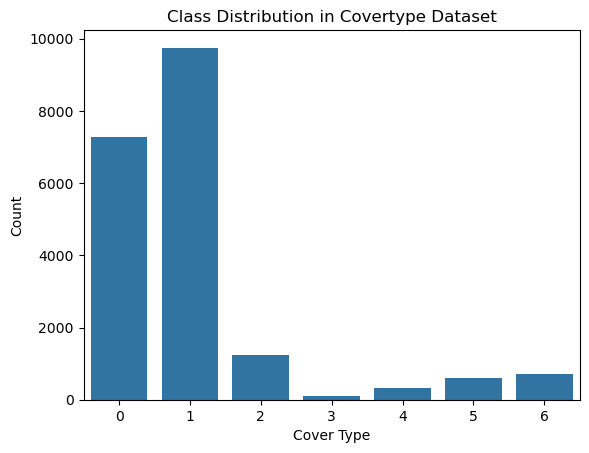

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y)
plt.title('Class Distribution in Covertype Dataset')
plt.xlabel('Cover Type')
plt.ylabel('Count')
plt.show()

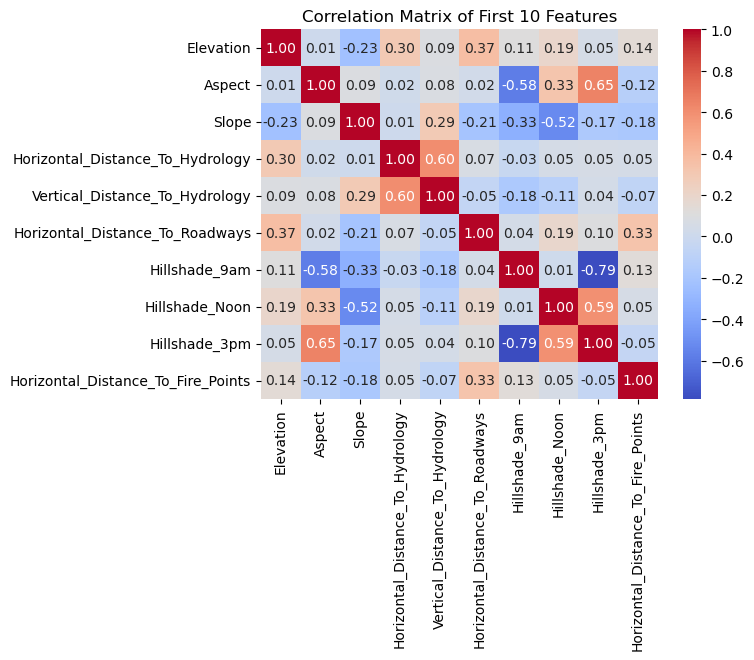

In [4]:
subset = X.iloc[:, :10]

# Compute correlation matrix
corr = subset.corr()

# Plot heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of First 10 Features')
plt.show()

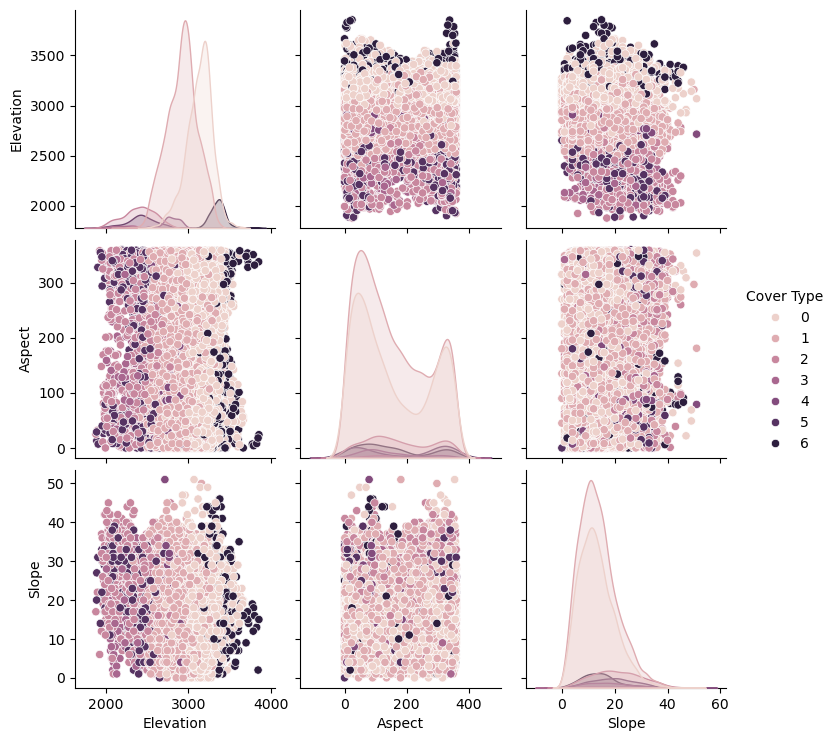

In [5]:
# Combine features and target for a sample
sample = X.iloc[:, :3].copy()  # First 3 features
sample['Cover Type'] = y

sns.pairplot(sample, hue='Cover Type', diag_kind='kde')
plt.show()

#Elevation - wysokość npm
#Aspect - ekspozycja (kierunek nachylenia stoku)
#Slope - nachylenie terenu (jak bardzo stromy jest teren)

In [6]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Split the dataset into training, validation and testing sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Initialize the CatBoost model with default settings
model = CatBoostClassifier(verbose=0, random_state=42)

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate accuracy
baseline_accuracy = accuracy_score(y_test, y_pred)

print(f"Baseline Accuracy: {baseline_accuracy * 100:.2f}%")

Baseline Accuracy: 83.43%


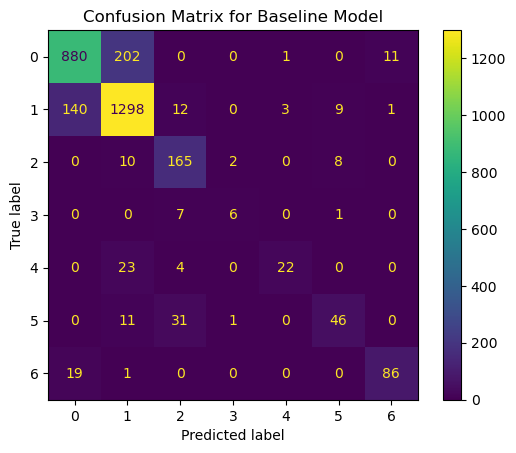

In [7]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.title('Confusion Matrix for Baseline Model')
plt.show()

In [10]:
import optuna
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score

def objective(trial):
    #hiperparametry
    params = {
        "iterations": trial.suggest_int("iterations", 100, 1000), #liczba drzew;
        "depth": trial.suggest_int("depth", 4, 10), #głębokość drzewa
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True), #jak duży krok robi model przy uczeniu
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10), #regularyzacja - pomaga ograniczyć przeuczenie
        "random_strength": trial.suggest_float("random_strength", 1e-3, 10, log=True), #dodaje losowość
        "border_count": trial.suggest_int("border_count", 32, 255), #liczba progów podziału dla cech numerycznych
        "loss_function": "MultiClass",
        "eval_metric": "Accuracy",
        "verbose": 0, #bez szczegolowych logow itp
        "random_state": 42
    }

    #Train CatBoost using params
    model = CatBoostClassifier(**params) #**wstaw caly slownik jako argument
    model.fit(X_train, y_train) #nauka

    y_pred = model.predict(X_valid) #predykcja na walidacji
    
    #Return validation accuracy score as result
    accuracy = accuracy_score(y_valid, y_pred) #porownanie przewidywan i rzeczywistosci

    return accuracy
    
    # Area for improvement: use Cross-Validation instead of a single train/val split.

In [11]:
# Create the study
study_name = 'catboost_optimization'
storage_name = 'sqlite:///example.db' 

#badanie optymalizacyjne
study = optuna.create_study(
    study_name=study_name, #nazwa eksperymentu
    storage=storage_name, # zapis wyników do pliku bazy danych
    direction='maximize', #maksymalizacja accuracy
    load_if_exists=True #korzystaj z bazy jesli juz istnieje
)
study.optimize(objective, n_trials=20)  # Run 20 trials

#najlepsza proba
print("Best trial:")
print(f"  Value (accuracy): {study.best_trial.value:.4f}") 
print("  Params:")
for key, value in study.best_trial.params.items():
    print(f"{key}: {value}")

[I 2026-04-17 00:55:59,918] Using an existing study with name 'catboost_optimization' instead of creating a new one.
[I 2026-04-17 00:56:12,420] Trial 20 finished with value: 0.804 and parameters: {'iterations': 527, 'depth': 6, 'learning_rate': 0.07174488873747963, 'l2_leaf_reg': 7.31389095188336, 'random_strength': 0.16099992827099638, 'border_count': 233}. Best is trial 20 with value: 0.804.
[I 2026-04-17 00:56:23,683] Trial 21 finished with value: 0.7953333333333333 and parameters: {'iterations': 839, 'depth': 5, 'learning_rate': 0.03386774997525238, 'l2_leaf_reg': 2.2360784941951017, 'random_strength': 0.01619403090015728, 'border_count': 149}. Best is trial 20 with value: 0.804.
[I 2026-04-17 00:57:13,825] Trial 22 finished with value: 0.7756666666666666 and parameters: {'iterations': 401, 'depth': 10, 'learning_rate': 0.011526318176623787, 'l2_leaf_reg': 7.632611570051251, 'random_strength': 0.08628039158063941, 'border_count': 95}. Best is trial 20 with value: 0.804.
[I 2026-04

Best trial:
  Value (accuracy): 0.8457
  Params:
iterations: 840
depth: 9
learning_rate: 0.12636462115370908
l2_leaf_reg: 5.754379119712327
random_strength: 1.0561377994079344
border_count: 119


In [13]:
import optuna_dashboard
optuna_dashboard.run_server("sqlite:///example.db")

Bottle v0.13.4 server starting up (using WSGIRefServer())...
Listening on http://localhost:8080/
Hit Ctrl-C to quit.

127.0.0.1 - - [17/Apr/2026 01:15:59] "GET / HTTP/1.1" 302 0
127.0.0.1 - - [17/Apr/2026 01:15:59] "GET /dashboard HTTP/1.1" 200 4145
127.0.0.1 - - [17/Apr/2026 01:16:00] "GET /static/bundle.js HTTP/1.1" 200 4159096
127.0.0.1 - - [17/Apr/2026 01:16:02] "GET /api/meta HTTP/1.1" 200 113
127.0.0.1 - - [17/Apr/2026 01:16:02] "GET /api/studies HTTP/1.1" 200 149
127.0.0.1 - - [17/Apr/2026 01:16:02] "GET /favicon.ico HTTP/1.1" 200 7670
C:\Users\wesol\anaconda3\envs\DataScience\Lib\site-packages\optuna_dashboard\_importance.py:71: ExperimentalWarning: PedAnovaImportanceEvaluator is experimental (supported from v3.6.0). The interface can change in the future.
  study, target=lambda t: t.values[objective_id], evaluator=PedAnovaImportanceEvaluator()
C:\Users\wesol\anaconda3\envs\DataScience\Lib\site-packages\optuna\importance\_ped_anova\evaluator.py:183: UserWarning: PedAnovaImporta

In [15]:
best_trial = study.best_trial

print(f"Best Trial Number: {best_trial.number}")
print(f"Best Validation Accuracy: {best_trial.value:.4f}")
print("Best Hyperparameters Found:")
for key, value in best_trial.params.items():
    print(f"  {key}: {value}")

Best Trial Number: 35
Best Validation Accuracy: 0.8457
Best Hyperparameters Found:
  iterations: 840
  depth: 9
  learning_rate: 0.12636462115370908
  l2_leaf_reg: 5.754379119712327
  random_strength: 1.0561377994079344
  border_count: 119


## Komentarz
Najlepsze znalezione hiperparametry mają sens. Model używa stosunkowo dużej liczby iteracji (840), co oznacza, że uczył się długo, ale nie osiągnął maksymalnej wartości (1000), więc zakres jest raczej dobrze dobrany. Głębokość drzewa (9) wskazuje na dość złożony model. Learning rate (~0.13) jest umiarkowany – nie za duży, nie za mały, co jest poprawne.
Żaden z parametrów nie osiąga skrajnych wartości zakresu (np. maksymalnej liczby iteracji), więc nie ma wyraźnej potrzeby rozszerzania przestrzeni przeszukiwania.
Najlepsza wartość accuracy (0.8457) to wynik uzyskany na zbiorze walidacyjnym, który Optuna maksymalizowała w trakcie optymalizacji.

In [16]:
best_params = best_trial.params

# --- IMPORTANT: Combine Training and Validation Data ---
# Create the full training dataset (train + validation) for the final model
X_train_full = pd.concat([X_train, X_valid], ignore_index=True)
y_train_full = pd.concat([y_train, y_valid], ignore_index=True)

final_params = best_params.copy()
final_params['random_state'] = 42

final_model = CatBoostClassifier(**final_params)
final_model.fit(X_train_full, y_train_full)

0:	learn: 1.6481352	total: 100ms	remaining: 1m 24s
1:	learn: 1.4608669	total: 190ms	remaining: 1m 19s
2:	learn: 1.3280307	total: 279ms	remaining: 1m 17s
3:	learn: 1.2283048	total: 378ms	remaining: 1m 19s
4:	learn: 1.1485676	total: 465ms	remaining: 1m 17s
5:	learn: 1.0825065	total: 554ms	remaining: 1m 16s
6:	learn: 1.0299217	total: 650ms	remaining: 1m 17s
7:	learn: 0.9777878	total: 738ms	remaining: 1m 16s
8:	learn: 0.9356721	total: 824ms	remaining: 1m 16s
9:	learn: 0.8989012	total: 920ms	remaining: 1m 16s
10:	learn: 0.8694831	total: 1.01s	remaining: 1m 16s
11:	learn: 0.8434632	total: 1.12s	remaining: 1m 17s
12:	learn: 0.8164209	total: 1.25s	remaining: 1m 19s
13:	learn: 0.7935225	total: 1.34s	remaining: 1m 18s
14:	learn: 0.7752416	total: 1.44s	remaining: 1m 19s
15:	learn: 0.7567598	total: 1.53s	remaining: 1m 18s
16:	learn: 0.7388752	total: 1.61s	remaining: 1m 18s
17:	learn: 0.7225394	total: 1.71s	remaining: 1m 17s
18:	learn: 0.7083347	total: 1.81s	remaining: 1m 18s
19:	learn: 0.6975406	t

CatBoostClassifier(border_count=119, depth=9, iterations=840, l2_leaf_reg=5.754379119712327, learning_rate=0.12636462115370908, random_state=42, random_strength=1.0561377994079344)

--- Performance Comparison ---
Baseline Accuracy (on Test Set): 83.43%
Optimized Accuracy (on Test Set): 85.47%
Improvement due to HPO: 2.03%
Confusion Matrix for Final Optimized Model (on Test Set):


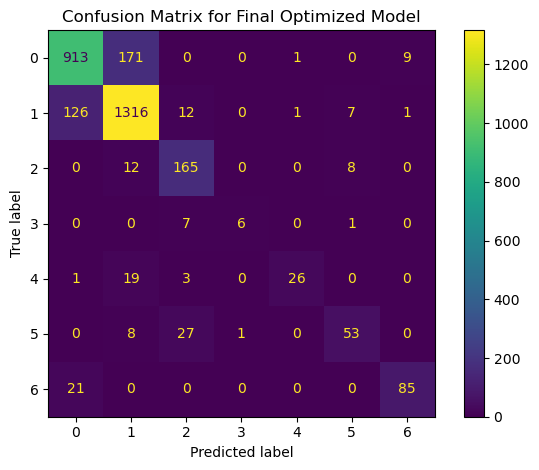

In [18]:
y_pred_test = final_model.predict(X_test)
final_accuracy = accuracy_score(y_test, y_pred_test)

print("--- Performance Comparison ---")
# Assuming baseline_accuracy variable holds the score from Step 5
print(f"Baseline Accuracy (on Test Set): {baseline_accuracy * 100:.2f}%")
print(f"Optimized Accuracy (on Test Set): {final_accuracy * 100:.2f}%")
improvement = final_accuracy - baseline_accuracy
print(f"Improvement due to HPO: {improvement * 100:.2f}%")

print("Confusion Matrix for Final Optimized Model (on Test Set):")
ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test)
plt.title('Confusion Matrix for Final Optimized Model')
plt.tight_layout()
plt.show()

## Komentarz:
Model dobrze radzi sobie z większością klas (wysokie wartości na przekątnej), ale widać, że myli niektóre klasy – szczególnie klasę 0 i 1 oraz kilka mniejszych klas, gdzie liczba błędów jest większa. Oznacza to, że model ma trudności z rozróżnieniem podobnych kategorii.

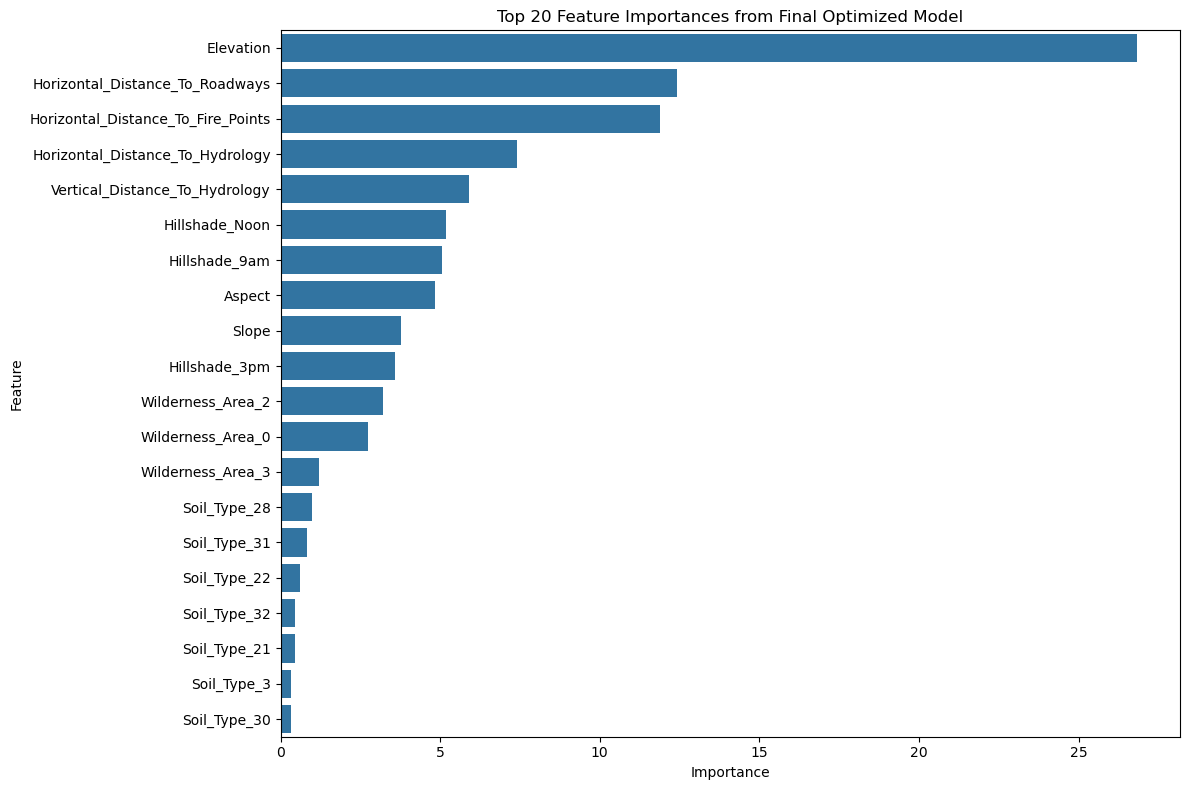

In [19]:
importances = final_model.get_feature_importance()
feature_names = X_train_full.columns

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importances (e.g., top 20)
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20)) # Plot top 20
plt.title('Top 20 Feature Importances from Final Optimized Model')
plt.tight_layout()
plt.show()

## Komentarz:
Najważniejszą cechą jest Elevation, która ma zdecydowanie największy wpływ na predykcję. Istotne są też odległości (np. do dróg, rzek) oraz cechy związane z terenem (np. nachylenie, nasłonecznienie). Cechy typu Soil_Type mają znacznie mniejsze znaczenie.